#  Data Science HW5 & HW6

 * 作業繳交期限 : 2021/05/12(三) 23:55</br>
 * 上傳作業之ipynb檔案，檔名固定為[學號-姓名.ipynb]，例：107379999-王大明.ipynb，未符合格式者將斟酌扣分</br>
 * 作業完成後至Google表單上傳檔案</br>
 * https://forms.gle/A8Y66owaE1HDBPn48 (請使用學校信箱)

 

In [ ]:
# import Google Drive 套件
from google.colab import drive
# 將自己的雲端硬碟掛載上去
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# 透過 gdrive/My Drive/... 來存取檔案
train = pd.read_csv('gdrive/My Drive/資料科學/上課講義 (共用)/1.資料視覺化/titanic_train.csv') #修改為你檔案放的路徑，gdrive/My Drive/指向雲端硬碟的根目錄
test = pd.read_csv('gdrive/My Drive/資料科學/上課講義 (共用)/1.資料視覺化/titanic_test.csv')

# Feature Selection</br> 
(使用RFE和Stepwise兩個方法做特徵選取)</br>
(40%)</br>
Y值為"Survived"，請預測Survived

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(train.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
# Display all informations
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
print(train.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


In [ ]:
# to get information three quartiles, mean, count, minimum and maximum values and the standard deviation.
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
train.shape

(891, 12)

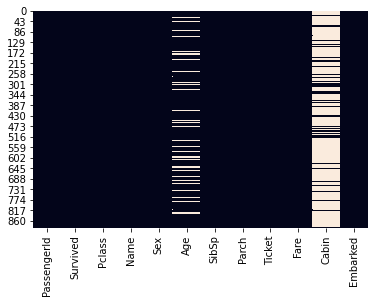

In [ ]:
# we are checking start with a pairplot, and check for missing values
import seaborn as sns

sns.heatmap(train.isnull(),cbar=False)

## Data pre-processing

In [ ]:
# Data Cleaning and Data Drop Process
train['Age'] = train['Age'].fillna(train['Age'].median())
# Change to categoric column to numeric
train.loc[train['Sex']=='male','Sex']=0
train.loc[train['Sex']=='female','Sex']=1
# instead of nan values
train['Embarked']=train['Embarked'].fillna('S') 
# Change to categoric column to numeric
train.loc[train['Embarked']=='S','Embarked']=0
train.loc[train['Embarked']=='C','Embarked']=1
train.loc[train['Embarked']=='Q','Embarked']=2

In [ ]:
# Drop unnecessary columns
drop_elements = ['Name','Cabin','Ticket']
train = train.drop(drop_elements, axis=1)

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


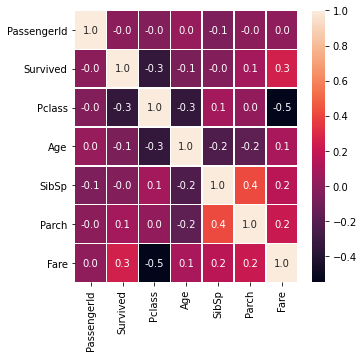

In [ ]:
# heatmap for train dataset
import matplotlib.pyplot as plt
f,ax = plt.subplots(figsize=(5, 5))
sns.heatmap(train.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

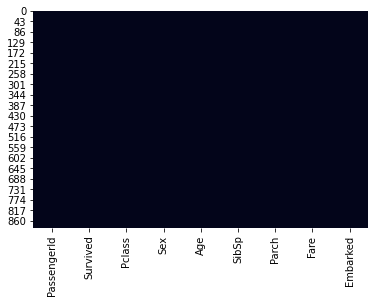

In [ ]:
# Now, data is clean and read to a analyze
sns.heatmap(train.isnull(),cbar=False)

In [ ]:
X = train.drop("Survived", axis= 1) #定義特徵變數
Y = train["Survived"]

## RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = train.drop("Survived", axis= 1) #定義特徵變數
y = train["Survived"] #定義目標變數
lin_reg = LinearRegression() 

rfe = RFE(lin_reg, 6) #建立RFE模型和挑選6個特徵
rfe.fit(X, y)

print(f"Number of selected features: {rfe.n_features_}\n\
Selected Features:", [feature for feature, rank in zip(X.columns.values, rfe.ranking_) if rank==1]) #列出挑選的6個變數

Number of selected features: 6
Selected Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']


## Stepwise

In [ ]:
import statsmodels.api as sm

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
def stepwise_selection(train, Survived,SL_in=0.05,SL_out = 0.05):
    initial_features = train.columns.tolist()
    best_features = []
    while (len(initial_features)>0):
        remaining_features = list(set(initial_features)-set(best_features))
        new_pval = pd.Series(index=remaining_features)
        for new_column in remaining_features:
            model = sm.OLS(Survived.astype(float), sm.add_constant(train[best_features+[new_column]]).astype(float)).fit()
            new_pval[new_column] = model.pvalues[new_column]
        min_p_value = new_pval.min()
        if(min_p_value<SL_in):
            best_features.append(new_pval.idxmin())
            while(len(best_features)>0):
                best_features_with_constant = sm.add_constant(train[best_features].astype(float))
                p_values = sm.OLS(Survived, best_features_with_constant).fit().pvalues[1:]
                max_p_value = p_values.max()
                if(max_p_value >= SL_out):
                    excluded_feature = p_values.idxmax()
                    best_features.remove(excluded_feature)
                else:
                    break 
        else:
            break
    return best_features

In [ ]:
stepwise_selection(X,Y)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


['Sex', 'Pclass', 'Age', 'SibSp', 'Embarked']

# Model training</br>
請使用Model Fit, Gridsearch兩種方法
(60%)

## Random Forest

### Import Module


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestRegressor

In [ ]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


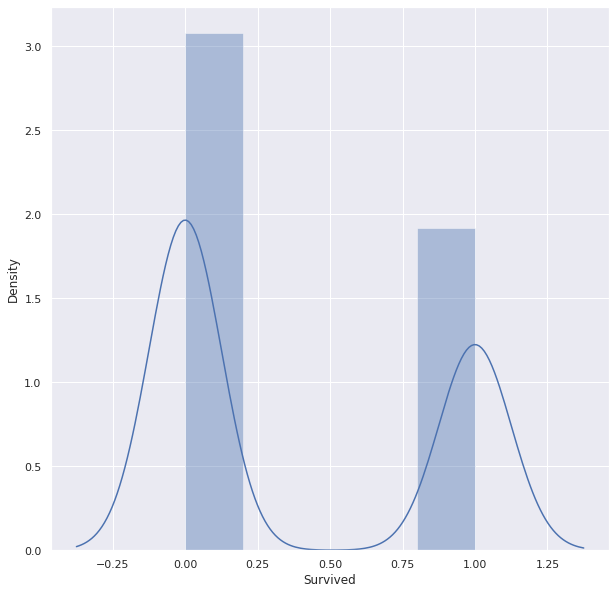

In [ ]:
# 用seaborn畫圖
sns.set(rc={'figure.figsize':(10,10)})
# 使用的資料是存活率Y
sns.distplot(train['Survived'])
plt.show()

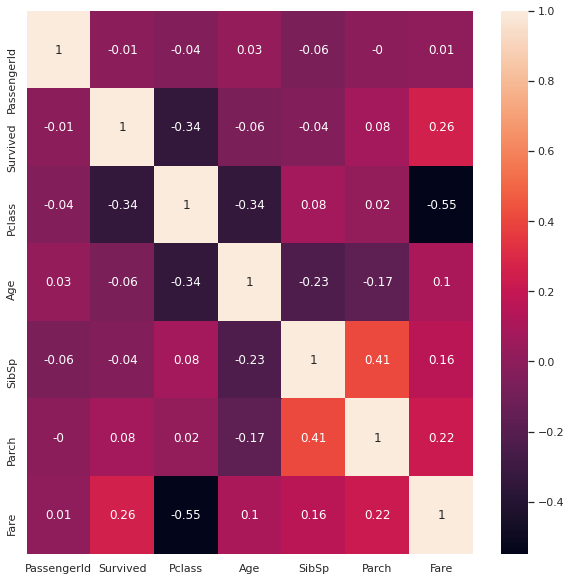

In [ ]:
correlation_matrix = train.corr().round(2)
# annot = True 讓我們可以把數字標進每個格子裡
sns.heatmap(data = correlation_matrix, annot = True)

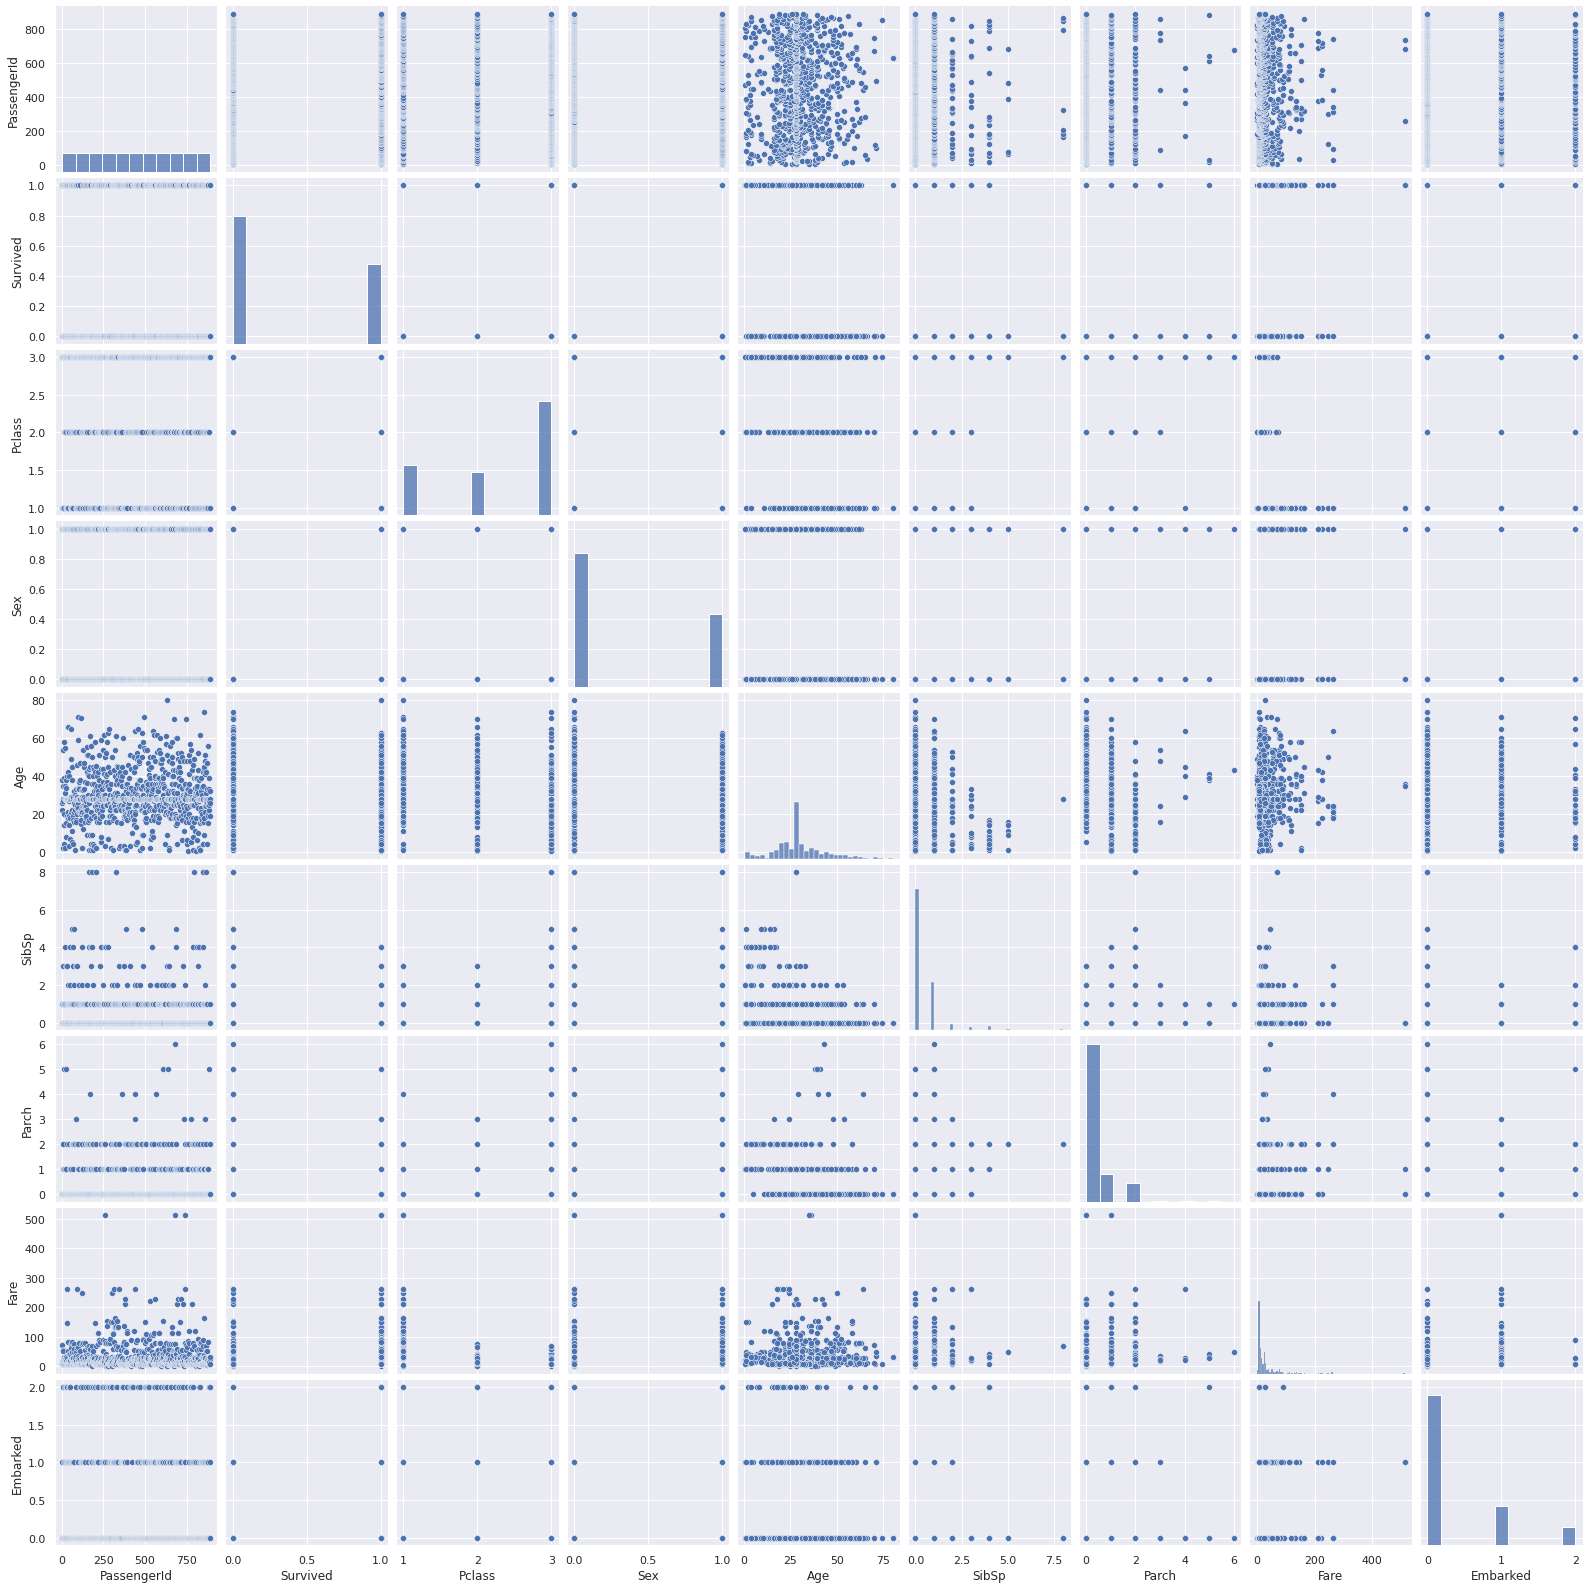

In [ ]:
sns.pairplot(train) 

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(train.drop('Survived', axis = 1), train['Survived'], test_size = 0.2, random_state=42)
X_train = X_train.astype('float')
X_test = X_test.astype('float')
Y_train = Y_train.astype('float')
Y_test = Y_test.astype('float')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Y_train', Y_train.shape)
print('Y_test', Y_test.shape)

X_train: (712, 8)
X_test: (179, 8)
Y_train (712,)
Y_test (179,)


In [ ]:
Y_test

709    1.0
439    0.0
840    0.0
720    1.0
39     1.0
      ... 
433    0.0
773    0.0
25     1.0
84     1.0
10     1.0
Name: Survived, Length: 179, dtype: float64

### Model training

In [ ]:
# Modeling
rf = RandomForestRegressor(n_estimators = 400, min_samples_leaf=0.12, random_state=123)

#Fitting Random Forest model
rf.fit(X_train, Y_train)

#Predicting using the Random Forest model
Y_pred = rf.predict(X_test)
Y_pred = pd.DataFrame(Y_pred).astype('int')
#Evaluate
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error(MSE):', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))


#Evaluate Classifier 
#print("Accuracy for Random Forest on CV data: ", metrics.accuracy_score(Y_test, Y_pred))

Mean Absolute Error(MAE): 0.4134078212290503
Mean Squared Error(MSE): 0.4134078212290503
Root Mean Squared Error(RMSE): 0.6429679783854327


### Feature selection

In [ ]:
from sklearn.feature_selection import SelectFromModel
sel = SelectFromModel(rf)
sel.fit(X_train, Y_train)

SelectFromModel(estimator=RandomForestRegressor(bootstrap=True, ccp_alpha=0.0,
                                                criterion='mse', max_depth=None,
                                                max_features='auto',
                                                max_leaf_nodes=None,
                                                max_samples=None,
                                                min_impurity_decrease=0.0,
                                                min_impurity_split=None,
                                                min_samples_leaf=0.12,
                                                min_samples_split=2,
                                                min_weight_fraction_leaf=0.0,
                                                n_estimators=400, n_jobs=None,
                                                oob_score=False,
                                                random_state=123, verbose=0,
                                                w

In [ ]:
sel.get_support()

array([False, False,  True, False, False, False, False, False])

In [ ]:
selected_feat = X_train.columns[(sel.get_support())]
print(selected_feat)

Index(['Sex'], dtype='object')


In [ ]:
X_important_train = sel.transform(X_train)
X_important_test = sel.transform(X_test)

In [ ]:
rf_important = RandomForestRegressor(n_estimators=400, random_state=123)
rf_important.fit(X_important_train, Y_train)
y_important_pred = rf_important.predict(X_important_test)
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(Y_test, y_important_pred))  
print('Mean Squared Error(MSE):', metrics.mean_squared_error(Y_test, y_important_pred)) 
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(Y_test, y_important_pred)))

Mean Absolute Error(MAE): 0.33704898182289217
Mean Squared Error(MSE): 0.17007778808677093
Root Mean Squared Error(RMSE): 0.4124048836844333


#### RandomForest before feature selection
Mean Absolute Error(MAE): 0.4134078212290503 <br>
Mean Squared Error(MSE): 0.4134078212290503 <br>
Root Mean Squared Error(RMSE): 0.6429679783854327 <br>

## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = { 
    'max_depth': [3,4,5,6],
    'min_samples_leaf':[0.04,0.06,0.08], 
    'max_features':[0.2,0.4,0.6,0.8]
}

In [ ]:
GridSearchCV_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv= 5)
GridSearchCV_rf.fit(X_train, Y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestRegressor(bootstrap=True, ccp_alpha=0.0,
                                             criterion='mse', max_depth=None,
                                             max_features='auto',
                                             max_leaf_nodes=None,
                                             max_samples=None,
                                             min_impurity_decrease=0.0,
                                             min_impurity_split=None,
                                             min_samples_leaf=0.12,
                                             min_samples_split=2,
                                             min_weight_fraction_leaf=0.0,
                                             n_estimators=400, n_jobs=None,
                                             oob_score=False, random_state=123,
                                             verbose=0, warm_start=False),
             iid='deprecated', n_

In [ ]:
GridSearchCV_rf.best_params_

{'max_depth': 4, 'max_features': 0.8, 'min_samples_leaf': 0.04}

In [ ]:
CV_rf = RandomForestRegressor(n_estimators=400, 
                max_features=0.8, 
                min_samples_leaf= 0.04, 
                max_depth = 6, 
                random_state=123)
CV_rf.fit(X_train, Y_train)
pred = CV_rf.predict(X_test)
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(Y_test, pred))  
print('Mean Squared Error(MSE):', metrics.mean_squared_error(Y_test, pred)) 
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(Y_test, pred)))

Mean Absolute Error(MAE): 0.28552354843939226
Mean Squared Error(MSE): 0.14179689249729857
Root Mean Squared Error(RMSE): 0.37655928151792856


# Evaluation</br>
請使用MAE, MSE, RMSE計算Loss

## Random Forest

In [ ]:
rf_important = RandomForestRegressor(n_estimators=400, random_state=123)
rf_important.fit(X_important_train, Y_train)
y_important_pred = rf_important.predict(X_important_test)
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(Y_test, y_important_pred))  
print('Mean Squared Error(MSE):', metrics.mean_squared_error(Y_test, y_important_pred)) 
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(Y_test, y_important_pred)))

Mean Absolute Error(MAE): 0.33704898182289217
Mean Squared Error(MSE): 0.17007778808677093
Root Mean Squared Error(RMSE): 0.4124048836844333


## GridSearchCV

In [ ]:
CV_rf = RandomForestRegressor(n_estimators=400, 
                max_features=0.8, 
                min_samples_leaf= 0.04, 
                max_depth = 6, 
                random_state=123)
CV_rf.fit(X_train, Y_train)
pred = CV_rf.predict(X_test)
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(Y_test, pred))  
print('Mean Squared Error(MSE):', metrics.mean_squared_error(Y_test, pred)) 
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(Y_test, pred)))

Mean Absolute Error(MAE): 0.28552354843939226
Mean Squared Error(MSE): 0.14179689249729857
Root Mean Squared Error(RMSE): 0.37655928151792856
